# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Naufal
- Email: naufalkz04@gmail.com
- Id Dicoding: muhammad_naufal_1603

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Menyiapkan data yang akan digunakan

In [ ]:
df = pd.read_csv("Employee-Dataset\employee_data.csv")
df

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,38,0.0,Travel_Rarely,168,Research & Development,1,3,Life Sciences,1,...,4,80,0,10,4,4,1,0,0,0
1466,1467,50,NaN,Travel_Rarely,813,Research & Development,17,5,Life Sciences,1,...,3,80,3,19,3,3,14,11,1,11
1467,1468,28,1.0,Travel_Rarely,1485,Research & Development,12,1,Life Sciences,1,...,4,80,0,1,4,2,1,1,0,0
1468,1469,40,0.0,Non-Travel,458,Research & Development,16,2,Life Sciences,1,...,2,80,1,6,0,3,4,2,0,0


**Insight:**
- Dataset employee berisi 1470 baris dan 35 kolom data yang didalamnya mencakup informasi pekerjaan, kompensasi, serta kepuasan kerja karyawan.
- Analisis ini diharapkan dapat membantu tim HR dalam merancang strategi retensi karyawan berbasis data.

## Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [ ]:
df.isna().sum().sort_values(ascending=False)

Attrition                   412
EmployeeId                    0
StandardHours                 0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StockOptionLevel              0
MonthlyIncome                 0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtCompany                0
YearsInCurrentRole            0
YearsSinceLastPromotion       0
MonthlyRate                   0
MaritalStatus                 0
Age                           0
JobSatisfaction               0
JobRole                       0
JobLevel                      0
JobInvolvement                0
HourlyRate                    0
Gender                        0
EnvironmentSatisfaction       0
EmployeeCount                 0
EducationField                0
Education                     0
DistanceFromHome              0
Departme

In [ ]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
print(f"Jumlah duplikasi: {df.duplicated().sum()}")

Jumlah duplikasi: 0


In [ ]:
df = df.drop(columns=['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1058 non-null   float64
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   object 
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   object 
 14  JobSatis

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

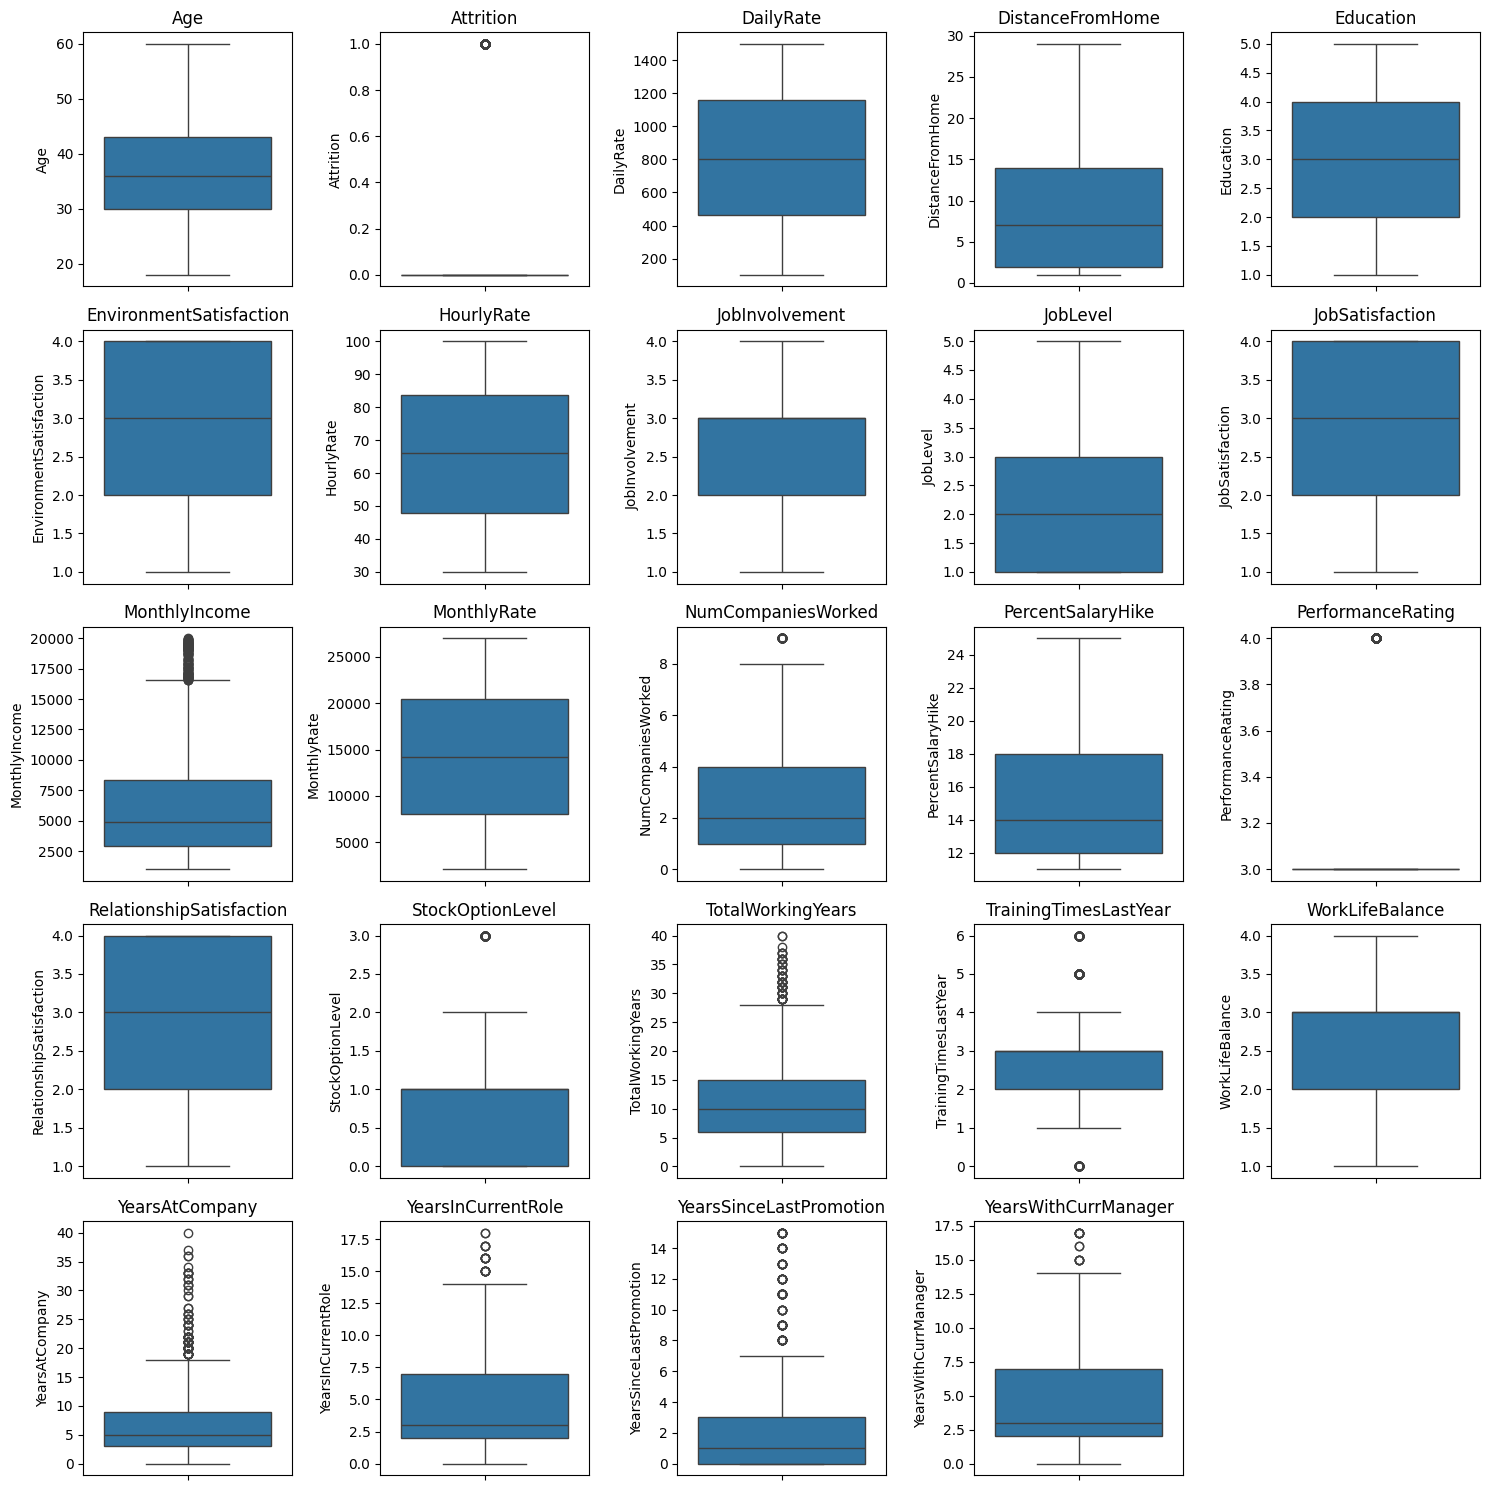

In [ ]:
import math

n_cols = 5  # jumlah kolom per baris
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15,n_rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
range_df = pd.DataFrame({
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'range': df[num_cols].max() - df[num_cols].min()
})

print(range_df.sort_values(by='range', ascending=False))

                             min      max    range
MonthlyRate               2094.0  26999.0  24905.0
MonthlyIncome             1009.0  19999.0  18990.0
DailyRate                  102.0   1499.0   1397.0
HourlyRate                  30.0    100.0     70.0
Age                         18.0     60.0     42.0
YearsAtCompany               0.0     40.0     40.0
TotalWorkingYears            0.0     40.0     40.0
DistanceFromHome             1.0     29.0     28.0
YearsInCurrentRole           0.0     18.0     18.0
YearsWithCurrManager         0.0     17.0     17.0
YearsSinceLastPromotion      0.0     15.0     15.0
PercentSalaryHike           11.0     25.0     14.0
NumCompaniesWorked           0.0      9.0      9.0
TrainingTimesLastYear        0.0      6.0      6.0
JobLevel                     1.0      5.0      4.0
Education                    1.0      5.0      4.0
JobSatisfaction              1.0      4.0      3.0
RelationshipSatisfaction     1.0      4.0      3.0
StockOptionLevel             0.

In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1058.0,0.169187,0.375094,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [ ]:
print("\nDistribusi nilai unik di setiap kolom")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Distribusi nilai unik di setiap kolom
Age: 43
Attrition: 2
BusinessTravel: 3
DailyRate: 886
Department: 3
DistanceFromHome: 29
Education: 5
EducationField: 6
EnvironmentSatisfaction: 4
Gender: 2
HourlyRate: 71
JobInvolvement: 4
JobLevel: 5
JobRole: 9
JobSatisfaction: 4
MaritalStatus: 3
MonthlyIncome: 1349
MonthlyRate: 1427
NumCompaniesWorked: 10
OverTime: 2
PercentSalaryHike: 15
PerformanceRating: 2
RelationshipSatisfaction: 4
StockOptionLevel: 4
TotalWorkingYears: 40
TrainingTimesLastYear: 7
WorkLifeBalance: 4
YearsAtCompany: 37
YearsInCurrentRole: 19
YearsSinceLastPromotion: 16
YearsWithCurrManager: 18


**Insight:**
- Ditemukan bahwa kolom attrition sebagai target variabel memiliki missing values sebanyak 412, sehingga perlu dilakukan penanganan khusus (drop) sebelum dianalisis lebih lanjut.
- Terdapat beberapa kolom yang tidak relevan untuk dianalisis seperti EmployeeCount, Over18, dan StandardHours, dihapus karena tidak memberikan informasi yang signifikan.
- Tidak terdapat duplikasi data, sehingga proses pembersihan data dapat lebih difokuskan pada penanganan missing values dan pemilihan fitur yang relevan.

## Data Preparation / Preprocessing

In [ ]:
df = df.dropna(subset=['Attrition'])
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [ ]:
df['Attrition'] = df['Attrition'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1058 non-null   int64 
 1   Attrition                 1058 non-null   int32 
 2   BusinessTravel            1058 non-null   object
 3   DailyRate                 1058 non-null   int64 
 4   Department                1058 non-null   object
 5   DistanceFromHome          1058 non-null   int64 
 6   Education                 1058 non-null   int64 
 7   EducationField            1058 non-null   object
 8   EnvironmentSatisfaction   1058 non-null   int64 
 9   Gender                    1058 non-null   object
 10  HourlyRate                1058 non-null   int64 
 11  JobInvolvement            1058 non-null   int64 
 12  JobLevel                  1058 non-null   int64 
 13  JobRole                   1058 non-null   object
 14  JobSatisfaction           105

In [ ]:
employee_df = df.copy()
employee_df

In [ ]:
# Binary encoding
binary_cols = {
    'Gender': {'Male': 0, 'Female': 1},
    'OverTime': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols.items():
    df[col] = df[col].map(mapping)

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,...,3,1,0,15,2,1,1,0,0,0
2,51,1,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,0,...,3,3,3,18,2,4,10,0,2,7
3,42,0,Travel_Frequently,555,Sales,26,3,Marketing,3,1,...,3,4,1,23,2,4,20,4,4,8
6,40,0,Travel_Rarely,1124,Sales,1,2,Medical,2,0,...,4,3,3,6,2,2,4,3,0,2
7,55,1,Travel_Rarely,725,Research & Development,2,3,Medical,4,0,...,3,4,1,24,2,3,5,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1,Non-Travel,1366,Research & Development,24,2,Technical Degree,2,0,...,3,1,0,10,2,2,10,7,1,9
1465,38,0,Travel_Rarely,168,Research & Development,1,3,Life Sciences,3,1,...,3,4,0,10,4,4,1,0,0,0
1467,28,1,Travel_Rarely,1485,Research & Development,12,1,Life Sciences,3,1,...,3,4,0,1,4,2,1,1,0,0
1468,40,0,Non-Travel,458,Research & Development,16,2,Life Sciences,3,0,...,3,2,1,6,0,3,4,2,0,0


In [ ]:
# One-hot encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_1
1,37,1,1141,11,2,1,61,1,2,2,...,False,False,False,False,False,False,False,True,False,False
2,51,1,1323,4,4,1,34,3,1,3,...,False,False,False,False,True,False,False,True,False,True
3,42,0,555,26,3,3,77,3,4,2,...,False,False,False,False,False,True,False,True,False,False
6,40,0,1124,1,2,2,57,1,2,4,...,False,False,False,False,False,True,False,True,False,True
7,55,1,725,2,3,4,78,3,5,1,...,False,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1,1366,24,2,2,72,2,3,1,...,False,False,False,False,False,False,False,False,True,False
1465,38,0,168,1,3,3,81,3,3,3,...,False,False,True,False,False,False,False,False,True,True
1467,28,1,1485,12,1,3,79,3,1,4,...,True,False,False,False,False,False,False,True,False,True
1468,40,0,458,16,2,3,74,3,1,3,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Ambil kolom numerik dari X_train
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns 

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

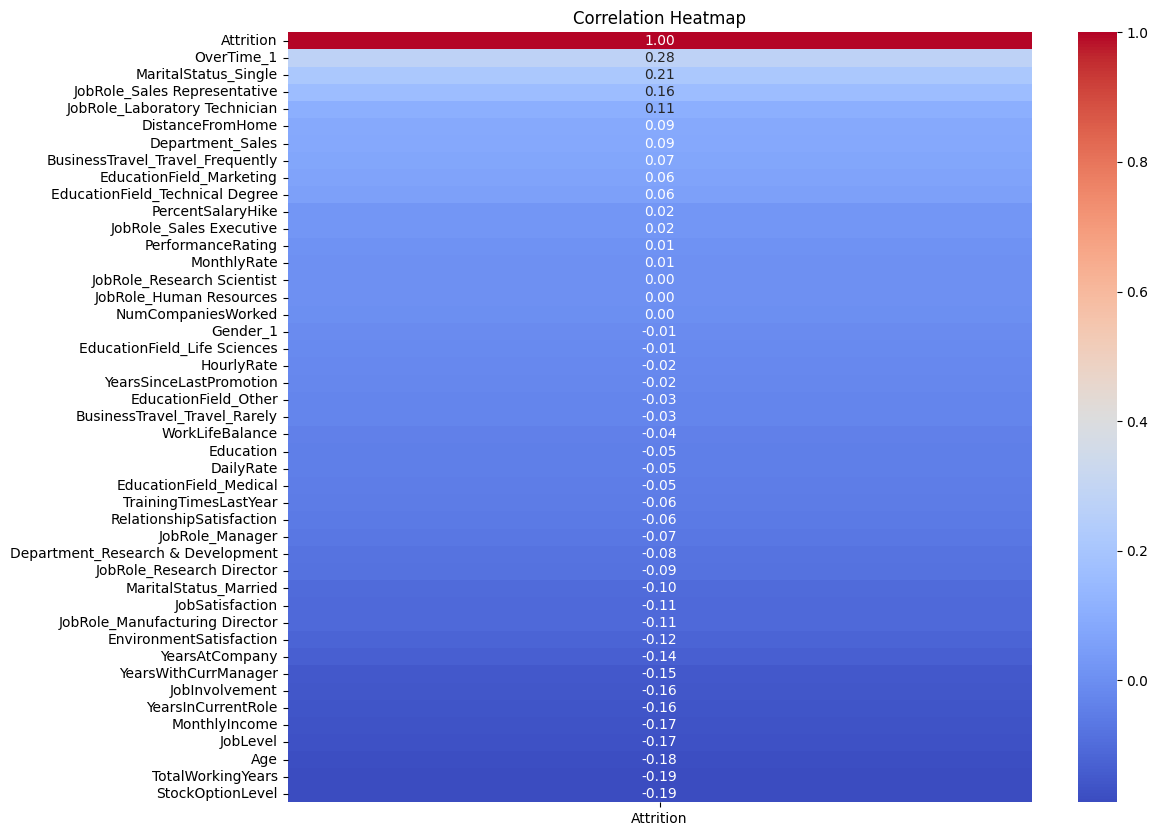

In [ ]:
train_df = pd.concat([X_train, y_train], axis=1)

# Hitung korelasi
correlation_matrix = train_df.corr()

# Ambil korelasi terhadap Attrition
corr_attrition = correlation_matrix['Attrition'].sort_values(ascending=False)


plt.figure(figsize=(12,10))
sns.heatmap(corr_attrition.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()  

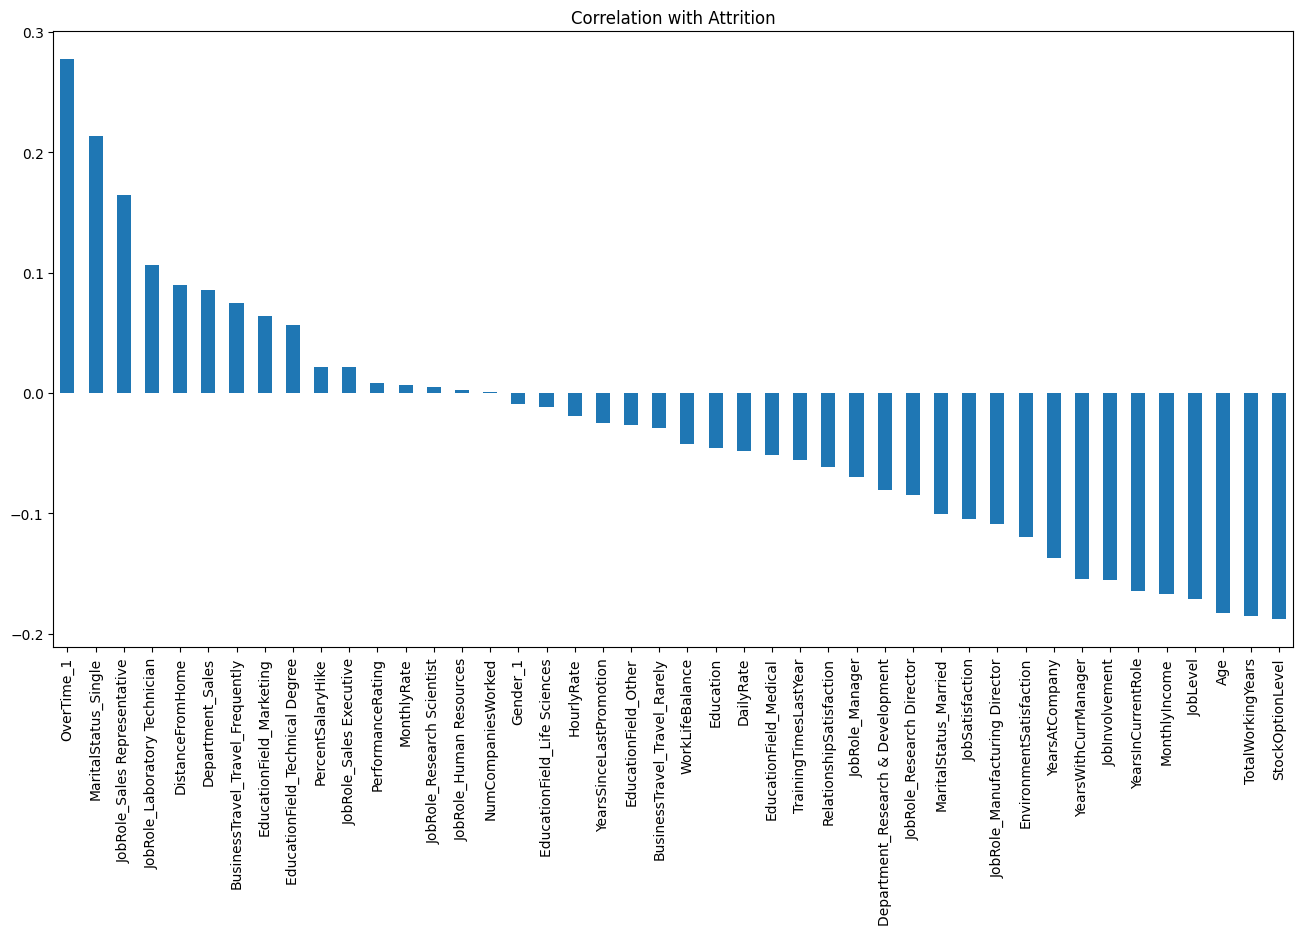

In [ ]:
correlation_with_target = correlation_matrix['Attrition'].sort_values(ascending=False)
plt.figure(figsize=(16,8))
correlation_with_target.drop('Attrition').plot(kind='bar')
plt.title("Correlation with Attrition")
plt.show()

In [ ]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_1
1,37,1,1141,11,2,1,61,1,2,2,...,False,False,False,False,False,False,False,True,False,False
2,51,1,1323,4,4,1,34,3,1,3,...,False,False,False,False,True,False,False,True,False,True
3,42,0,555,26,3,3,77,3,4,2,...,False,False,False,False,False,True,False,True,False,False
6,40,0,1124,1,2,2,57,1,2,4,...,False,False,False,False,False,True,False,True,False,True
7,55,1,725,2,3,4,78,3,5,1,...,False,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1,1366,24,2,2,72,2,3,1,...,False,False,False,False,False,False,False,False,True,False
1465,38,0,168,1,3,3,81,3,3,3,...,False,False,True,False,False,False,False,False,True,True
1467,28,1,1485,12,1,3,79,3,1,4,...,True,False,False,False,False,False,False,True,False,True
1468,40,0,458,16,2,3,74,3,1,3,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
employee_df.to_csv("employee_clean_data.csv", index=False)

## Modeling

## Evaluation